# Multiplexed USP
In the tensor factorization methods for quantum chemistry outlined in [Google's THC paper](https://arxiv.org/abs/2011.03494), one of the more mysterious subroutines is _multiplexed USP_. This subroutine does what it says on the tin: given a set of integer values (loaded into the quantum computer by, e.g. QROM), prepare a superposition of uniform superposition states.

The prescription for how to perform multiplexed USP is given explicitly in the above paper, although it is difficult to find if you don't already know where to look. The recipe is given in step 3. (a) of the double factorization compilation in Appendix C (page 52 of [the arXiv pdf version](https://arxiv.org/pdf/2011.03494.pdf)).

The actual procedure is very simple (assuming you already know how USP works, which will _not_ be explained in this notebook). Instead of a single rotation angle, we multiplex over a bunch of different angles. Instead of a classical comparator, we use a quantum comparator where the value is loaded in via QROM. This is essentially all that needs to change, with one caveat that needs its own explanation.

## The Contiguizer
The first step in USP is to perform Hadamards on all of the qubits that the state will eventually be loaded into. One only needs to perform Hadamards on "active" qubits -- so if one wanted to load 6 uniform amplitudes into a state, they would need Hadamards on 3 qubits. When performing USP in superposition over multiple values, the number of Hadamards needed will be different, so one needs to be careful about how many are performed for any given branch of the iterations. The solution the Google folk came up with was to use a _contiguized_ register, which is a lot more useful than its cryptic name suggests. Essentially, it creates a new register and fills it with `1`s up to the bit length of a given number (e.g. the bit length of 6 is 3, since 6 in binary is `110` -- the contiguized register would therefore load `111`). Since this can be done in superposition, this new register can then be used to perform a series of controlled Hadamards.

In Workbench Algorithms, we have a [`Contiguizer`](../autoapi/workbench_algorithms/subroutines/multiplexed_usp.html#workbench_algorithms.subroutines.multiplexed_usp.Contiguizer) `Qubrick` that performs this operation. The circuit and its output are shown below.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from psiqworkbench import QPU, Qubits
from workbench_algorithms import (
    USP,
    MultiplexedRealUSP,
    MultiplexedUSP,
    Contiguizer,
    ZeroAncMultiplexor,
    OneAncMultiplexor,
    SawtoothMultiplexor,
    BinaryTreeMultiplexor
)
import numpy as np

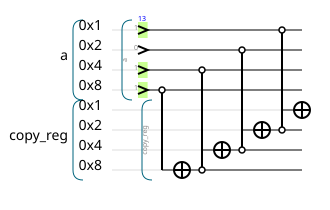

In [3]:
qc = QPU()
val = 13
num_qubits = val.bit_length()

qc.reset(2 * num_qubits)

a = Qubits(num_qubits, "a", qc)

a.write(val)

cont = Contiguizer()

cont.compute(a)

b = cont.get_result_qreg()

qc.draw()

... and let's check it's doing the right thing...

In [4]:
qc = QPU()
for val in range(1, 20):
    num_qubits = val.bit_length()

    qc.reset(2 * num_qubits)

    a = Qubits(num_qubits, "a", qc)

    a.write(val)

    cont = Contiguizer()

    cont.compute(a)

    b = cont.get_result_qreg()

    print((1 << val.bit_length()) - 1 == b.read())

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


Success! Now onto multiplexed USP itself.

There are currently two multiplexed USP `Qubricks`: [`MultiplexedUSP`](../autoapi/workbench_algorithms/subroutines/multiplexed_usp.html#workbench_algorithms.subroutines.multiplexed_usp.MultiplexedUSP) and [`MultiplexedRealUSP`](../autoapi/workbench_algorithms/subroutines/multiplexed_usp.html#workbench_algorithms.subroutines.multiplexed_usp.MultiplexedRealUSP), corresponding to two of the different USP implementations in WBA. These take a contiguizer (which defaults to `Contiguizer`) and a `Multiplexor` Qubrick:

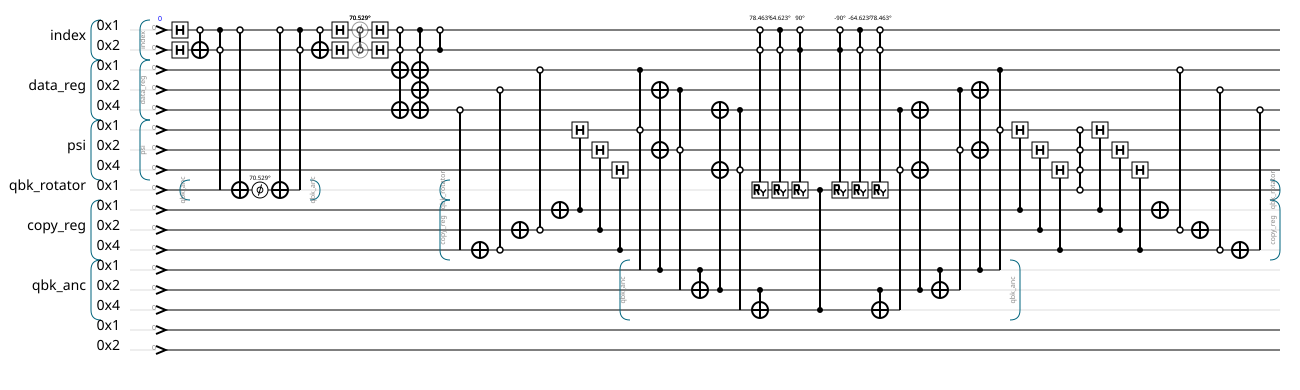

In [5]:
# the USP states we're going to multiplex over
data = [5, 7, 8]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data)))) +1

qc.reset(num_qubits + int(np.ceil(np.log2(len(data)))))

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedRealUSP(multiplexor=ZeroAncMultiplexor())

# setup fake "QROM reg"
usp = USP()

# load the data into the fake "QROM"
qc.write(0)
usp.compute(len(data), index)
for i, val in enumerate(data):
    data_reg.x(val, index == i)

# compute the multiplexed USP
musp.compute(psi, index, data_reg, data)

qc.draw()

What's going on in this test? In essence, multiplexed USP takes a list of `d` values and prepares a superposition of uniform states with dimensions given by each of the `d` values. Those `d` values are loaded into the `data_reg`, typically using a QROM and we use `index` to perform the quantum `for` loop over the different values.

Instead of using a proper QROM, here we will cheat a little, as we're just showing the functionality of multiplexed USP and because the data should be loaded in _before_ calling the multiplexed USP qubrick. We start by preparing a uniform superposition in the `index` register, meaning that our final state will be a uniform superposition of the different `d` values we request. We then use a simple fake "QROM" to load each `d` value into the `data_reg` register using the `index == i` syntax. We loop over the `data`, compute the multiplexor and then postselect on the `index` register having value `idx`. If our multiplexed USP does the right thing, the postselected state should be a uniform state with dimension given by the `idx`th element of `data`, so the final step is to loop over the amplitudes of `psi` (into which we loaded our multiplexed USP state) and verify that we got the right USP state.

Does it do the right thing?

In [6]:
# the USP states we're going to multiplex over
# data = [5, 7, 2, 3, 1]
data = list(range(1, 8))

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data)))) + 1

qc.reset(num_qubits+5)

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedRealUSP(multiplexor=SawtoothMultiplexor())

# setup fake "QROM reg"
usp = USP()

# loop over the data, postselect on the index register and check we get a USP over the psi register
for idx, d in enumerate(data):
    qc.write(0)
    usp.compute(len(data), index)

    qc.label("data")
    for i, val in enumerate(data):
        data_reg.x(val, index == i)
    qc.label()

    musp.compute(psi, index, data_reg, data)

    index.postselect(idx)

    for psi_idx in range(d):
        print(np.isclose(psi.peek_read_probability(psi_idx), 1 / d))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


Yup! Success!

We can swap out the `Multiplexor` `Qubrick` for any other implementation:

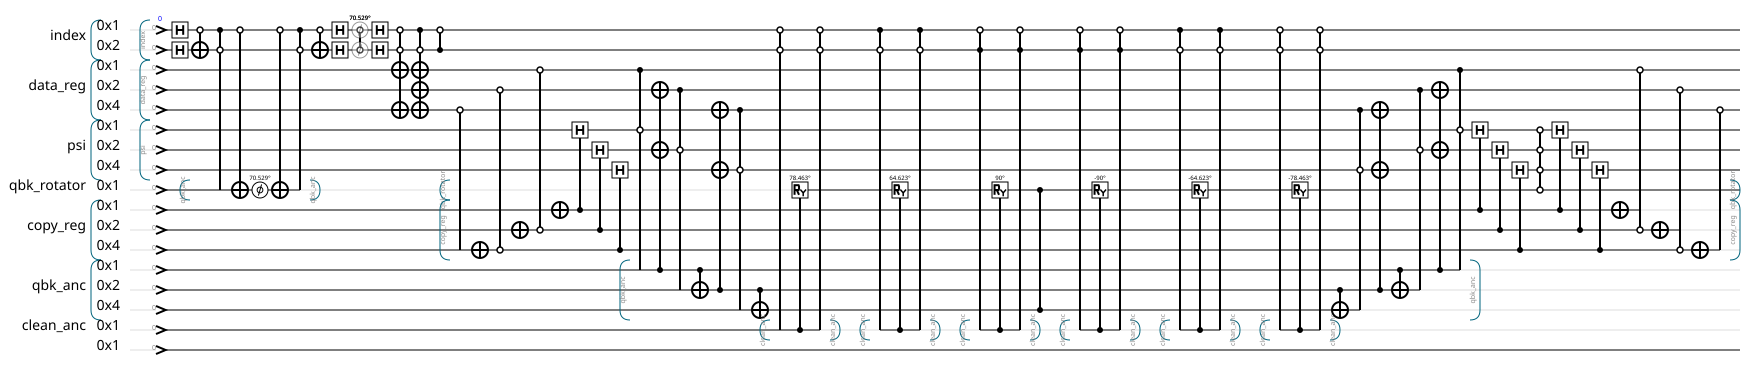

In [7]:
# the USP states we're going to multiplex over
data = [5, 7, 8]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data)))) +1

qc.reset(num_qubits + int(np.ceil(np.log2(len(data)))))

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedRealUSP(multiplexor=OneAncMultiplexor())

# setup fake "QROM reg"
usp = USP()

qc.write(0)
usp.compute(len(data), index)
for i, val in enumerate(data):
    data_reg.x(val, index == i)

# compute the multiplexed USP
musp.compute(psi, index, data_reg, data)

qc.draw()

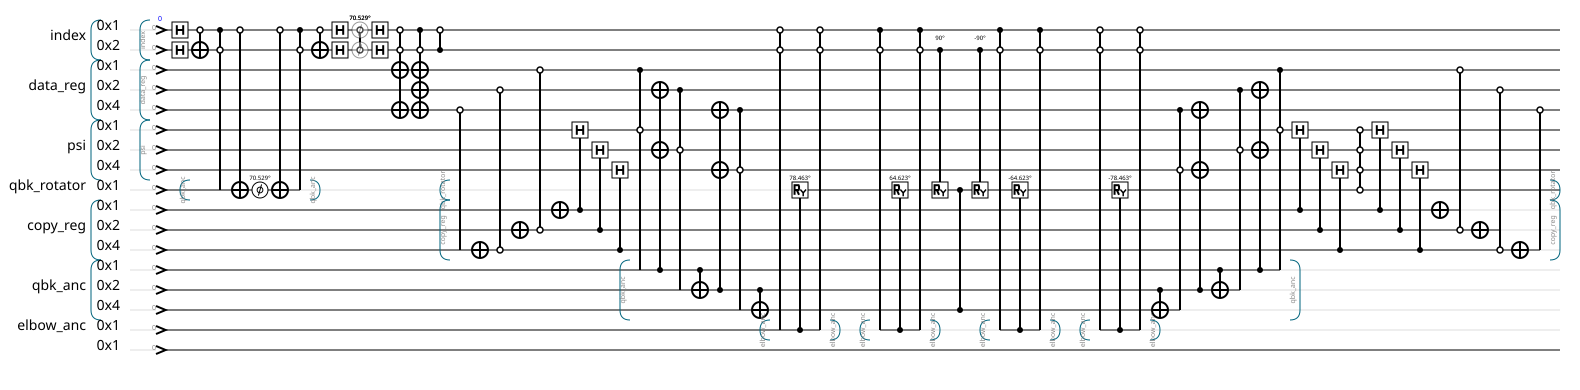

In [8]:
# the USP states we're going to multiplex over
data = [5, 7, 8]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data)))) +1

qc.reset(num_qubits + int(np.ceil(np.log2(len(data)))))

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedRealUSP(multiplexor=SawtoothMultiplexor())

# setup fake "QROM reg"
usp = USP()

qc.write(0)
usp.compute(len(data), index)
for i, val in enumerate(data):
    data_reg.x(val, index == i)

# compute the multiplexed USP
musp.compute(psi, index, data_reg, data)

qc.draw()

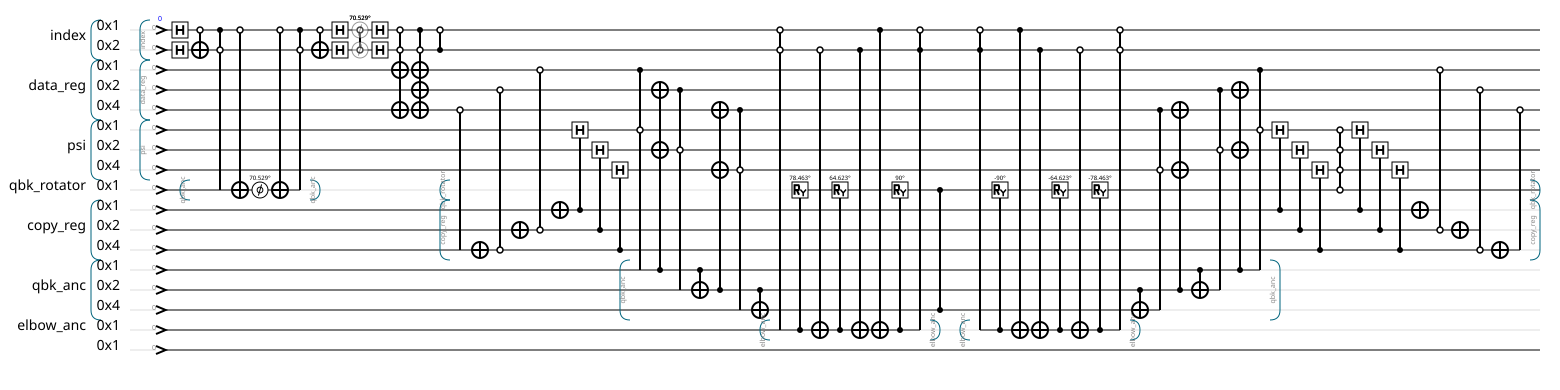

In [9]:
# the USP states we're going to multiplex over
data = [5, 7, 8]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data)))) +1

qc.reset(num_qubits + int(np.ceil(np.log2(len(data)))))

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedRealUSP(multiplexor=BinaryTreeMultiplexor())

# setup fake "QROM reg"
usp = USP()

qc.write(0)
usp.compute(len(data), index)
for i, val in enumerate(data):
    data_reg.x(val, index == i)

# compute the multiplexed USP
musp.compute(psi, index, data_reg, data)

qc.draw()

The other implementation is based off `USP` and more closely follows the literature reference:

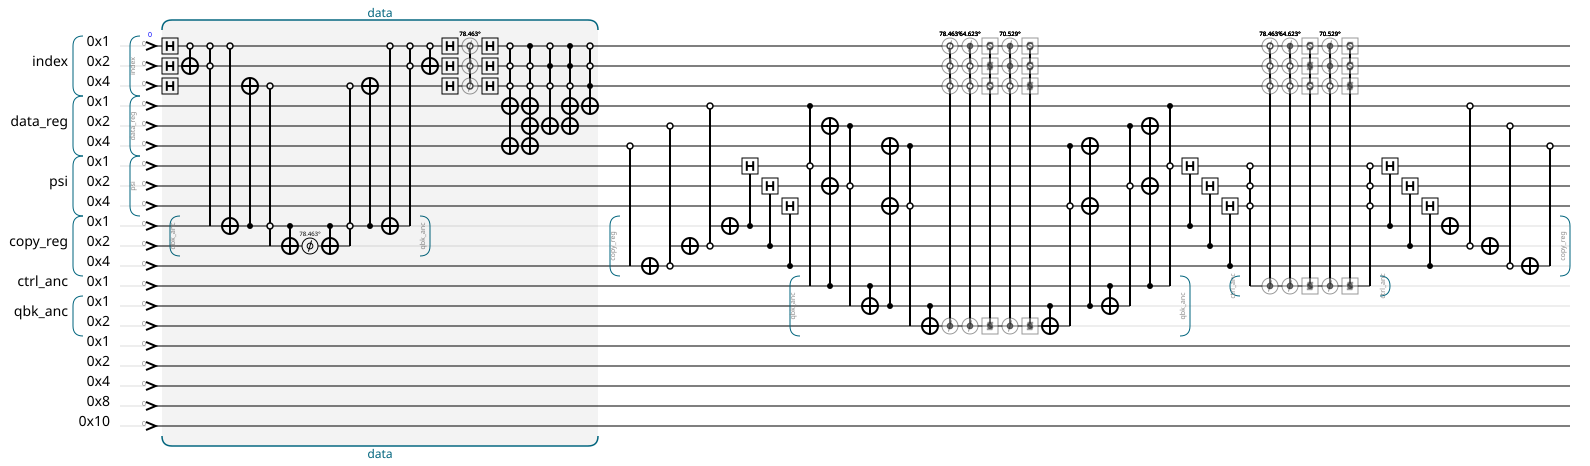

In [10]:
# the USP states we're going to multiplex over
data = [5, 7, 2, 3, 1]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data))))

qc.reset(num_qubits + 5)

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedUSP(multiplexor=ZeroAncMultiplexor())

# setup fake "QROM reg"
usp = USP()
qc.write(0)
qc.label("data")
usp.compute(len(data), index)
for i, val in enumerate(data):
    data_reg.x(val, index == i)
qc.label()

# compute the multiplexed USP
musp.compute(psi, index, data_reg, data)

qc.draw()

In [11]:
# the USP states we're going to multiplex over
data = [5, 7, 2, 3, 1]

qc = QPU()

num_qubits = int(np.ceil(np.log2(len(data)))) + 4 * int(np.ceil(np.log2(max(data))))

qc.reset(num_qubits+5)

index = Qubits(int(np.ceil(np.log2(len(data)))), "index", qc)
data_reg = Qubits(int(np.ceil(np.log2(max(data)))), "data_reg", qc)
psi = Qubits(len(data_reg), "psi", qc)

musp = MultiplexedUSP(multiplexor=ZeroAncMultiplexor())

# setup fake "QROM reg"
usp = USP()

# loop over the data, postselect on the index register and check we get a USP over the psi register
for idx, d in enumerate(data):
    qc.write(0)
    usp.compute(len(data), index)

    qc.label("data")
    for i, val in enumerate(data):
        data_reg.x(val, index == i)
    qc.label()

    musp.compute(psi, index, data_reg, data)

    index.postselect(idx)

    for psi_idx in range(d):
        print(np.isclose(psi.peek_read_probability(psi_idx), 1 / d))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
